# 📈 Tema 25: Regresión Logística y Modelado de Probabilidades

¡Bienvenido/a al estudio de la Regresión Logística!

A pesar de llevar la palabra "Regresión" en su nombre, este es uno de los algoritmos de **Clasificación** más utilizados en la industria (desde aprobaciones de créditos bancarios hasta diagnósticos médicos). A lo largo de este cuaderno, aprenderemos cómo transformar una combinación lineal de variables en una probabilidad acotada estrictamente entre $0$ y $1$, y cómo optimizar sus coeficientes utilizando diferentes solucionadores estadísticos.

## 🚀 Contenido del Cuaderno

1. **Fundamentos Conceptuales:** La Función Sigmoide, los *odds* y la Máxima Verosimilitud.
2. **Visualización Matemática:** Graficando el comportamiento de la Sigmoide.
3. **Métricas de Diagnóstico Avanzado:** La Curva ROC y el Área Bajo la Curva (AUC).
4. **Proyecto Práctico:** Clasificación de Medicamentos por Origen de Proveedor (`drugs.csv`).
5. **Evaluación de Solucionadores:** Comparativa entre `lbfgs`, `newton-cg`, `sag` y `saga`, y análisis del modelo elegido.
6. **Nivel Pro:** Diseñando un Pipeline de Clasificación Automatizado con OOP.
7. **Glosario Técnico, Errores Comunes y Conclusión.**

## 🎯 Al terminar este cuaderno podrás

* Explicar por qué la regresión logística modela **probabilidades** y cómo se interpretan sus coeficientes (*odds ratio*).
* Entrenar, comparar y evaluar un clasificador con `scikit-learn` sin caer en errores típicos (fuga de datos, codificación incorrecta, escalado omitido).
* Leer una **curva ROC**, un **AUC** y elegir un **umbral de decisión** según el costo de cada error.
* Empaquetar todo el flujo en un `Pipeline` reutilizable con Programación Orientada a Objetos.

---
> **Instrucciones:** Ejecuta las celdas de forma secuencial. Asegúrate de tener el archivo `drugs.csv` en tu directorio de trabajo.
> Este cuaderno fue ejecutado con `scikit-learn` 1.8 (requiere `scikit-learn` ≥ 1.0 y `pandas` ≥ 1.1).

## 1. Fundamentos: Función Sigmoide, Odds y Máxima Verosimilitud

### 1.1 El problema de usar una recta para clasificar

Una regresión lineal simple predice una recta que va desde el infinito negativo al infinito positivo. Esto no nos sirve para clasificar: una probabilidad **nunca** puede ser menor a $0$ ni mayor a $1$.

### 1.2 La solución: combinación lineal + sigmoide

La Regresión Logística toma la ecuación lineal clásica:
$$z = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_n X_n$$

Y la introduce dentro de la **Función Sigmoide** (también conocida como función logística):
$$S(z) = \frac{1}{1 + e^{-z}}$$

La función sigmoide actúa como un "embudo" o transformador: sin importar si el valor de $z$ es un número inmenso o extremadamente negativo, la salida siempre estará contenida de forma suave en el rango $(0, 1)$, representando la **probabilidad de pertenecer a la clase positiva**.

Propiedades que conviene memorizar:

* $S(0) = 0.5$ → la **frontera de decisión** (umbral $0.5$) corresponde exactamente a $z = 0$.
* $S(z) \to 1$ cuando $z \to +\infty$ y $S(z) \to 0$ cuando $z \to -\infty$.
* Simetría: $S(-z) = 1 - S(z)$.
* Derivada: $S'(z) = S(z)\,\bigl(1 - S(z)\bigr)$, lo que simplifica mucho el cálculo del gradiente durante el entrenamiento.

### 1.3 Interpretación: *odds* y log-odds (logit)

Si despejamos $z$ de la sigmoide obtenemos el **logit**:
$$\ln\!\left(\frac{p}{1-p}\right) = z = \beta_0 + \beta_1 X_1 + \dots + \beta_n X_n$$

* $\dfrac{p}{1-p}$ son los ***odds*** (razón de probabilidades). Si $p = 0.8$, los odds son $4$ (a favor $4$ a $1$).
* El modelo es **lineal en el log-odds**, no en la probabilidad.
* Aumentar $X_j$ en una unidad suma $\beta_j$ al log-odds, es decir, **multiplica los odds por $e^{\beta_j}$** (el *odds ratio*), manteniendo las demás variables constantes.
  * $\beta_j > 0$ → $e^{\beta_j} > 1$ → la probabilidad de la clase positiva **sube**.
  * $\beta_j < 0$ → $e^{\beta_j} < 1$ → la probabilidad **baja**.
  * $\beta_j \approx 0$ → la variable casi no influye.

### 1.4 ¿Cómo aprende el algoritmo? (Máxima Verosimilitud)

En lugar de usar Mínimos Cuadrados (como en regresión lineal), los coeficientes $\beta$ se estiman mediante **Máxima Verosimilitud (Maximum Likelihood Estimation, MLE)**. Este método busca los parámetros que maximicen la probabilidad de haber observado las etiquetas reales del dataset.

Para cada observación $i$ con probabilidad predicha $p_i = S(z_i)$ y etiqueta real $y_i \in \{0, 1\}$, la verosimilitud es $p_i^{\,y_i}(1-p_i)^{1-y_i}$. Tomando logaritmos y sumando sobre todas las observaciones:
$$\ell(\boldsymbol{\beta}) = \sum_{i=1}^{n} \Bigl[\, y_i \ln p_i + (1-y_i)\ln(1-p_i) \Bigr]$$

Maximizar $\ell(\boldsymbol\beta)$ equivale a minimizar la **log-loss** (entropía cruzada binaria) $-\ell(\boldsymbol\beta)/n$. Esta función **no tiene solución cerrada**, por eso se resuelve con algoritmos de optimización numérica como el *Descenso de Gradientes* o el método de *Newton-Raphson* (los "solucionadores" que compararemos en la sección 5).

> 💡 **Dos matices importantes**
> 1. La log-loss es una función **convexa**: tiene un único mínimo global. Por eso, si todos los solucionadores convergen, deberían llegar prácticamente al **mismo modelo** (lo verificaremos en la sección 5).
> 2. `scikit-learn` **no maximiza la verosimilitud pura**: por defecto añade una penalización **L2** controlada por el parámetro `C` (`C = 1.0`; a menor `C`, mayor penalización). Estrictamente es una *máxima verosimilitud penalizada*. Esto evita que los coeficientes exploten cuando las clases son perfectamente separables, pero también significa que **la escala de las variables importa** (lo veremos en la sección 5.2).

### 1.5 Configuración inicial

Importamos todas las librerías en una sola celda (buena práctica: las dependencias quedan visibles al inicio) y definimos una semilla y una paleta de colores para que los resultados y gráficos sean **reproducibles y consistentes** en todo el cuaderno.

In [1]:
# --- CONFIGURACIÓN INICIAL: librerías, semilla y estilo ---
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, roc_curve, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler

SEMILLA = 42                    # semilla global para reproducibilidad

COLOR_PRINCIPAL = '#2c3e50'     # azul pizarra
COLOR_ALERTA    = '#e74c3c'     # rojo
COLOR_NEUTRO    = '#95a5a6'     # gris
COLOR_ACENTO    = '#2980b9'     # azul
plt.rcParams.update({'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--'})

print("✅ Configuración lista.")

✅ Configuración lista.


## 2. Visualización Matemática: la Sigmoide en acción

Vamos a graficar dos cosas:

* **Izquierda:** la sigmoide estándar $S(z)$, con el umbral clásico de $0.5$.
* **Derecha:** cómo cambian los coeficientes la forma de la curva cuando hay **una sola variable** $x$ y $z = \beta_0 + \beta_1 x$.

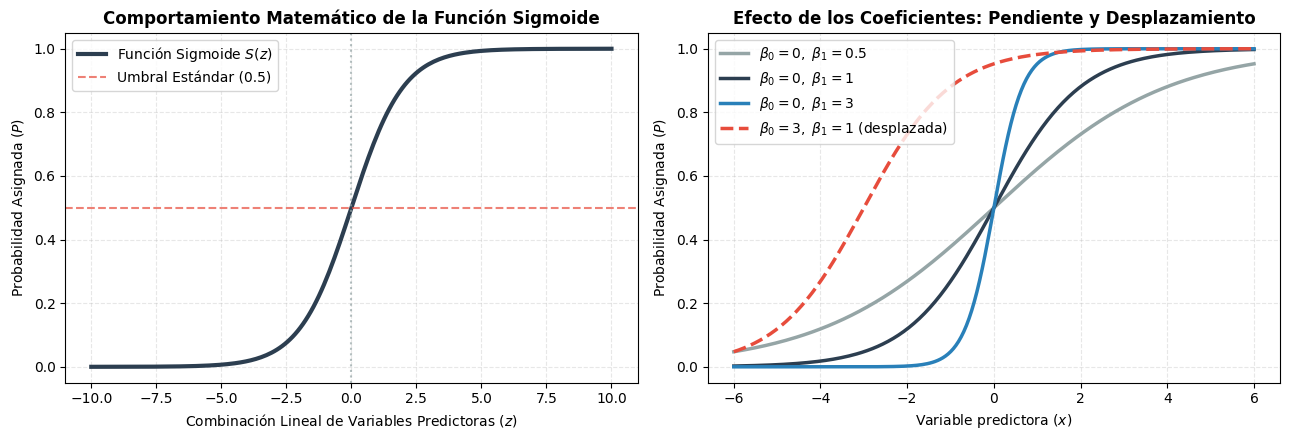

✅ Gráfica conceptual generada con éxito como 'demostracion_sigmoide.png'.


In [2]:
# --- DEMOSTRACIÓN CONCEPTUAL: LA CURVA SIGMOIDE ---
def calcular_sigmoide(z):
    """Función sigmoide S(z) = 1 / (1 + e^(-z))."""
    return 1 / (1 + np.exp(-z))

# Generamos un rango de valores de combinación lineal desde -10 hasta 10
valores_z = np.linspace(-10, 10, 200)
probabilidades = calcular_sigmoide(valores_z)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# ---- Panel izquierdo: la sigmoide estándar ----
ax1.plot(valores_z, probabilidades, color=COLOR_PRINCIPAL, linewidth=3, label='Función Sigmoide $S(z)$')
ax1.axhline(0.5, color=COLOR_ALERTA, linestyle='--', alpha=0.7, label='Umbral Estándar (0.5)')
ax1.axvline(0.0, color=COLOR_NEUTRO, linestyle=':', alpha=0.7)
ax1.set_title('Comportamiento Matemático de la Función Sigmoide', fontsize=12, fontweight='bold')
ax1.set_xlabel('Combinación Lineal de Variables Predictoras ($z$)')
ax1.set_ylabel('Probabilidad Asignada ($P$)')
ax1.set_ylim(-0.05, 1.05)
ax1.legend(loc='upper left')

# ---- Panel derecho: efecto de los coeficientes en z = b0 + b1 * x ----
x = np.linspace(-6, 6, 200)
for beta1, color in [(0.5, COLOR_NEUTRO), (1, COLOR_PRINCIPAL), (3, COLOR_ACENTO)]:
    ax2.plot(x, calcular_sigmoide(beta1 * x), color=color, linewidth=2.5, label=rf'$\beta_0=0,\ \beta_1={beta1}$')
ax2.plot(x, calcular_sigmoide(1 * x + 3), color=COLOR_ALERTA, linewidth=2.5, linestyle='--',
         label=r'$\beta_0=3,\ \beta_1=1$ (desplazada)')
ax2.set_title('Efecto de los Coeficientes: Pendiente y Desplazamiento', fontsize=12, fontweight='bold')
ax2.set_xlabel('Variable predictora ($x$)')
ax2.set_ylabel('Probabilidad Asignada ($P$)')
ax2.set_ylim(-0.05, 1.05)
ax2.legend(loc='upper left')

plt.tight_layout()
# guardamos el gráfico siguiendo las buenas prácticas de visualización estructurada
plt.savefig('demostracion_sigmoide.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Gráfica conceptual generada con éxito como 'demostracion_sigmoide.png'.")

**Cómo leer el gráfico de la derecha**

* **$\beta_1$ controla la pendiente:** con $\beta_1 = 3$ la curva pasa de $0$ a $1$ en un rango muy estrecho (el modelo es "más seguro" al separar las clases); con $\beta_1 = 0.5$ la transición es suave y gradual.
* **$\beta_0$ desplaza la curva** horizontalmente: la frontera de decisión ($P = 0.5$) ocurre en $x = -\beta_0 / \beta_1$. Con $\beta_0 = 3$ y $\beta_1 = 1$ la frontera se corre a $x = -3$.

Ahora veamos la relación **$z$ → probabilidad → odds → log-odds** con números concretos. Fíjate que la columna `ln(Odds)` es idéntica a `z`: ese es el significado del *logit*.

In [3]:
# --- TABLA DE EQUIVALENCIAS: z -> probabilidad -> odds -> log-odds ---
tabla_z = pd.DataFrame({'z': [-4, -2, -1, 0, 1, 2, 4]})
tabla_z['P = S(z)'] = calcular_sigmoide(tabla_z['z'])
tabla_z['Odds = P/(1-P)'] = tabla_z['P = S(z)'] / (1 - tabla_z['P = S(z)'])
tabla_z['ln(Odds)'] = np.log(tabla_z['Odds = P/(1-P)'])
display(tabla_z.round(4))

# Nota de estabilidad numérica: np.exp(-z) desborda para z muy negativos (z < -709).
# En producción se usa scipy.special.expit(z), que es la sigmoide numéricamente estable.

,z,P = S(z),Odds = P/(1-P),ln(Odds)
0,-4,0.0180,0.0183,-4.0
1,-2,0.1192,0.1353,-2.0
2,-1,0.2689,0.3679,-1.0
3,0,0.5000,1.0000,0.0
4,1,0.7311,2.7183,1.0
5,2,0.8808,7.3891,2.0
6,4,0.9820,54.5982,4.0


## 3. Evaluación del Modelo con Curva ROC y AUC

Cuando el modelo nos devuelve una probabilidad (ej. $0.65$), necesitamos un **Umbral de Clasificación** para tomar una decisión final. Por defecto, si la probabilidad es $\ge 0.5$, se clasifica como clase positiva ($1$); si es menor, como clase negativa ($0$).

Sin embargo, en medicina o finanzas, mover el umbral puede salvar vidas o millones de dólares. Para evaluar el rendimiento del modelo sin depender de un único umbral estático, utilizamos la **Curva ROC (Receiver Operating Characteristic)**.

### 3.1 Matriz de confusión: la base de todo

|                     | **Predicho: Positivo (1)** | **Predicho: Negativo (0)** |
|---------------------|:--------------------------:|:--------------------------:|
| **Real: Positivo**  | VP (verdadero positivo)    | FN (falso negativo)        |
| **Real: Negativo**  | FP (falso positivo)        | VN (verdadero negativo)    |

* **Eje Y de la ROC — Tasa de Verdaderos Positivos (TPR / Sensibilidad / *Recall*):** $\dfrac{VP}{VP + FN}$. Qué porcentaje de los casos positivos reales logramos atrapar correctamente.
* **Eje X de la ROC — Tasa de Falsos Positivos (FPR / 1 − Especificidad):** $\dfrac{FP}{FP + VN}$. Qué porcentaje de falsas alarmas lanzamos sobre casos que eran realmente negativos.

Cada punto de la curva corresponde a **un umbral distinto**: bajar el umbral captura más positivos (sube el TPR) pero también genera más falsas alarmas (sube el FPR). La curva muestra ese *trade-off* completo.

### 3.2 El AUC

El **AUC (Área bajo la curva)** resume la ROC en un solo número entre $0$ y $1$:

* $AUC = 1.0$ → perfección predictiva absoluta.
* $AUC = 0.5$ → equivale a **lanzar una moneda** (la diagonal de la gráfica).
* $AUC < 0.5$ → peor que el azar (las predicciones están invertidas).

Interpretación probabilística: el AUC es la probabilidad de que el modelo asigne una probabilidad **mayor a un positivo elegido al azar que a un negativo elegido al azar**.

> ⚠️ **Limitaciones del AUC:** mide qué tan bien el modelo *ordena* los casos, pero no si las probabilidades están bien *calibradas* (un modelo puede tener AUC alto y decir "0.99" cuando la probabilidad real es 0.7). Por eso, cuando nos importa la probabilidad en sí (modelado de probabilidades), también miramos la **log-loss**. Además, con clases muy desbalanceadas conviene complementar con la curva Precisión–Recall.

### 3.3 Construyamos una ROC a mano (ejemplo de juguete)

Con solo 10 pacientes podemos ver cómo se construye la curva: probamos cada probabilidad como umbral y calculamos TPR y FPR. Verificaremos además la interpretación probabilística del AUC comparando **todos los pares** (positivo, negativo).

,Umbral,TPR (Sensibilidad),FPR (1 - Especificidad)
0,inf,0.0,0.0
1,0.95,0.2,0.0
2,0.85,0.4,0.0
3,0.70,0.6,0.0
4,0.60,0.6,0.2
5,0.55,0.8,0.2
6,0.40,0.8,0.4
7,0.35,1.0,0.4
8,0.30,1.0,0.6
9,0.20,1.0,0.8


AUC (sklearn)                 : 0.880
P(score positivo > negativo)  : 0.880   <- deben coincidir


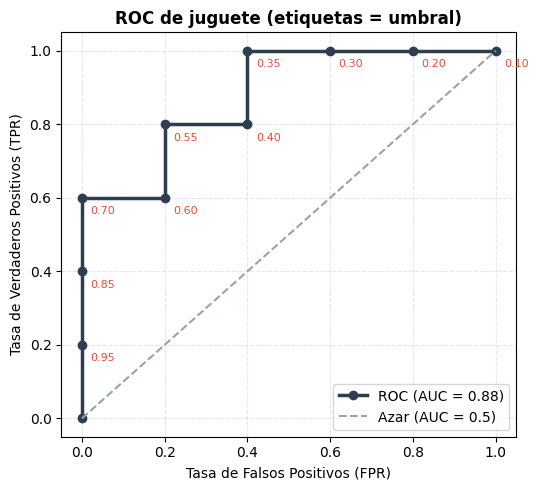

In [4]:
# --- ROC PASO A PASO: EJEMPLO DE JUGUETE (10 pacientes, 5 positivos y 5 negativos) ---
y_real   = np.array([0,    0,    0,    1,    0,    1,    0,    1,    1,    1])
p_modelo = np.array([0.10, 0.20, 0.30, 0.35, 0.40, 0.55, 0.60, 0.70, 0.85, 0.95])

fpr_j, tpr_j, umbrales_j = roc_curve(y_real, p_modelo, drop_intermediate=False)
tabla_roc = pd.DataFrame({'Umbral': umbrales_j,
                          'TPR (Sensibilidad)': tpr_j,
                          'FPR (1 - Especificidad)': fpr_j})
display(tabla_roc.round(3))

# AUC según sklearn vs. definición probabilística (comparación de todos los pares)
auc_sklearn = roc_auc_score(y_real, p_modelo)
positivos, negativos = p_modelo[y_real == 1], p_modelo[y_real == 0]
auc_pares = np.mean([1.0 if p > n else 0.5 if p == n else 0.0 for p in positivos for n in negativos])
print(f"AUC (sklearn)                 : {auc_sklearn:.3f}")
print(f"P(score positivo > negativo)  : {auc_pares:.3f}   <- deben coincidir")

# Gráfica de la ROC de juguete, anotando el umbral de cada punto
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr_j, tpr_j, marker='o', color=COLOR_PRINCIPAL, linewidth=2.5, label=f'ROC (AUC = {auc_sklearn:.2f})')
ax.plot([0, 1], [0, 1], linestyle='--', color=COLOR_NEUTRO, label='Azar (AUC = 0.5)')
for f, t, u in zip(fpr_j[1:], tpr_j[1:], umbrales_j[1:]):
    ax.annotate(f'{u:.2f}', (f, t), textcoords='offset points', xytext=(6, -12), fontsize=8, color=COLOR_ALERTA)
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('ROC de juguete (etiquetas = umbral)', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Observaciones:**

* La primera fila (umbral `inf`) no clasifica a nadie como positivo → punto $(0, 0)$. La última (umbral bajo) clasifica **a todos** como positivos → punto $(1, 1)$.
* Cada vez que el umbral baja y "cruza" un positivo real, la curva **sube**; cuando "cruza" un negativo, **avanza hacia la derecha**.
* El AUC calculado por `scikit-learn` coincide con la fracción de pares (positivo, negativo) bien ordenados: esa es su interpretación probabilística.

---
## 4. 📝 Proyecto Práctico: Clasificación por Origen de Proveedor

**Problema Farmacéutico:** Disponemos de la base de datos histórica de pacientes `drugs.csv`. El departamento de compras e investigación médica requiere modelar si el medicamento adecuado para un futuro paciente será de **Origen Nacional** o de **Origen Extranjero**.

De acuerdo con la ficha del problema, los fármacos se distribuyen de la siguiente manera:
* **Proveedor Nacional (Clase Positiva = 1):** Fármaco A, Fármaco B y Fármaco C.
* **Proveedor Extranjero (Clase Negativa = 0):** Fármaco X y Fármaco Y.

**Objetivos del paso a paso:**
1. Cargar e inspeccionar el dataset.
2. Mapear y transformar la variable objetivo `Drug` en la regla binaria de proveedores (Nacional/Extranjero).
3. Codificar las características categóricas independientes usando `LabelEncoder()` (según la ficha) y entender sus limitaciones.
4. Dividir en entrenamiento/prueba y estandarizar sin fuga de datos.
5. Entrenar la Regresión Logística evaluando 4 solucionadores de optimización: `lbfgs`, `newton-cg`, `sag` y `saga` (sección 5).
6. Analizar la eficacia del algoritmo óptimo mediante su reporte de clasificación y gráfico ROC (sección 5.3).

### 4.1 Carga e inspección del dataset

Antes de modelar siempre inspeccionamos los datos: tamaño, tipos, nulos y cómo se comporta cada variable respecto al objetivo.

In [5]:
# --- PASO 4.1: CARGA E INSPECCIÓN ---
try:
    df_original = pd.read_csv('drugs.csv')
except FileNotFoundError:
    raise FileNotFoundError(f"No se encontró 'drugs.csv' en el directorio de trabajo: {os.getcwd()}")

print(f"Filas: {df_original.shape[0]} | Columnas: {df_original.shape[1]}")
print(f"Valores nulos totales: {int(df_original.isna().sum().sum())}\n")
display(df_original.head())

print("\n=== Tipos de dato ===")
print(df_original.dtypes.to_string())

print("\n=== Frecuencia de cada fármaco (tal como viene en el archivo) ===")
print(df_original['Drug'].value_counts().to_string())

print("\n=== Na_to_K (relación sodio/potasio) por fármaco ===")
display(df_original.groupby('Drug')['Na_to_K'].agg(['min', 'mean', 'max']).round(2))

Filas: 200 | Columnas: 6
Valores nulos totales: 0



,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY



=== Tipos de dato ===
Age              int64
Sex                str
BP                 str
Cholesterol        str
Na_to_K        float64
Drug               str

=== Frecuencia de cada fármaco (tal como viene en el archivo) ===
Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16

=== Na_to_K (relación sodio/potasio) por fármaco ===


,min,mean,max
Drug,,,
DrugY,15.02,22.37,38.25
drugA,6.27,10.92,13.97
drugB,8.62,11.52,14.24
drugC,6.77,10.63,14.16
drugX,6.68,10.65,14.64


**Qué observar:**

* Hay **3 variables categóricas** (`Sex`, `BP`, `Cholesterol`) que deben convertirse a números, y **2 numéricas** (`Age`, `Na_to_K`).
* Este dataset suele circular con **capitalización inconsistente** en la columna `Drug` (por ejemplo `DrugY` con "D" mayúscula frente a `drugX`, `drugA`...). Una comparación exacta de texto fallaría **sin avisar**: por eso normalizaremos los nombres antes de mapearlos.
* `Na_to_K` es una señal muy fuerte: los valores de `DrugY` no se solapan con los de los demás fármacos (su mínimo supera al máximo de todos los demás). Como `DrugY` es de proveedor **Extranjero**, esperamos que `Na_to_K` alto empuje la probabilidad hacia la clase 0.

### 4.2 Construcción de la variable objetivo binaria

Mapeamos con un **diccionario explícito** (en lugar de un `if/else` con `else: return 0`) para que un fármaco inesperado o mal escrito **no se clasifique silenciosamente como Extranjero**. Además validamos que no quede ningún valor sin mapear.

In [6]:
# --- PASO 4.2: TRANSFORMACIÓN DE LA VARIABLE OBJETIVO SEGÚN PROVEEDOR ---
# Nacional (A, B, C) -> 1 | Extranjero (X, Y) -> 0
PROVEEDOR_POR_FARMACO = {'druga': 1, 'drugb': 1, 'drugc': 1,    # Nacional
                         'drugx': 0, 'drugy': 0}                # Extranjero

nombre_normalizado = df_original['Drug'].str.strip().str.lower()   # ignora mayúsculas/espacios
y_binario = nombre_normalizado.map(PROVEEDOR_POR_FARMACO)

# Validación: si aparece un fármaco no contemplado, detenemos el flujo con un mensaje claro
desconocidos = df_original.loc[y_binario.isna(), 'Drug'].unique()
assert len(desconocidos) == 0, f"Fármacos no contemplados en la regla de negocio: {desconocidos}"
y_binario = y_binario.astype(int)

X_features = df_original.drop(columns='Drug')

print("=== Verificación del mapeo (fármaco original vs. clase binaria) ===")
display(pd.crosstab(df_original['Drug'], y_binario.rename('Proveedor (1=Nacional)')))

conteo = y_binario.value_counts()
print("\n=== Distribución del Target de Negocio ===")
print(f"Medicamentos de Proveedor Extranjero (0): {conteo[0]} casos ({conteo[0]/len(y_binario)*100:.1f}%)")
print(f"Medicamentos de Proveedor Nacional (1):   {conteo[1]} casos ({conteo[1]/len(y_binario)*100:.1f}%)")

linea_base = conteo.max() / len(y_binario)
print(f"\n📌 Línea base: un modelo que siempre responde 'Extranjero' acertaría el {linea_base*100:.1f}% de las veces.")

=== Verificación del mapeo (fármaco original vs. clase binaria) ===


Proveedor (1=Nacional),0,1
Drug,,
DrugY,91,0
drugA,0,23
drugB,0,16
drugC,0,16
drugX,54,0



=== Distribución del Target de Negocio ===
Medicamentos de Proveedor Extranjero (0): 145 casos (72.5%)
Medicamentos de Proveedor Nacional (1):   55 casos (27.5%)

📌 Línea base: un modelo que siempre responde 'Extranjero' acertaría el 72.5% de las veces.


**Por qué importa la línea base:** las clases están **desbalanceadas** (la clase Extranjero es la mayoritaria). Un modelo "tonto" que siempre predice la clase mayoritaria ya obtiene esa *accuracy*. Cualquier modelo que construyamos debe **superar claramente ese número**; y, como la *accuracy* sola puede engañar, también miraremos *precision*, *recall*, F1, AUC y log-loss.

### 4.3 Codificación de variables categóricas con `LabelEncoder`

`LabelEncoder` convierte cada categoría en un entero. Para no reutilizar (y pisar) el mismo objeto, creamos **un encoder por columna** y los guardamos en un diccionario; así podemos inspeccionar el mapeo de cada uno y reutilizarlo después.

In [7]:
# --- PASO 4.3: CODIFICACIÓN DE VARIABLES INDEPENDIENTES CON LabelEncoder ---
X_codificado = X_features.copy()
encoders = {}                                   # un LabelEncoder por columna

for columna in ['Sex', 'BP', 'Cholesterol']:
    encoders[columna] = LabelEncoder()
    X_codificado[columna] = encoders[columna].fit_transform(X_codificado[columna])
    mapeo = {categoria: int(codigo) for codigo, categoria in enumerate(encoders[columna].classes_)}
    print(f"{columna:12s} -> {mapeo}")

display(X_codificado.head())

Sex          -> {'F': 0, 'M': 1}
BP           -> {'HIGH': 0, 'LOW': 1, 'NORMAL': 2}
Cholesterol  -> {'HIGH': 0, 'NORMAL': 1}


,Age,Sex,BP,Cholesterol,Na_to_K
0,23,0,0,0,25.355
1,47,1,1,0,13.093
2,47,1,1,0,10.114
3,28,0,2,0,7.798
4,61,0,1,0,18.043


> ⚠️ **Advertencia importante sobre `LabelEncoder` en variables predictoras**
>
> * `LabelEncoder` está pensado para codificar la **variable objetivo** (`y`). Para las variables predictoras `scikit-learn` ofrece `OrdinalEncoder` y `OneHotEncoder`. Lo usamos aquí porque así lo pide la ficha del problema, pero hay que conocer su trampa.
> * Asigna los códigos en **orden alfabético**, no clínico: `BP` queda como `HIGH=0, LOW=1, NORMAL=2`. Un modelo lineal interpreta ese número como una **escala numérica**: supone que el salto `HIGH → LOW` pesa lo mismo que `LOW → NORMAL`.
> * En este dataset el resultado sale bien, pero en parte por **casualidad**: el orden alfabético pone `NORMAL` en un extremo de la escala, y `NORMAL` es justamente la categoría que nunca corresponde a un fármaco Nacional. En la **sección 6.1** lo demostraremos comparando tres codificaciones y veremos por qué `OneHotEncoder` es la opción segura.
> * Codificar *antes* de dividir train/test no genera fuga de datos aquí (las categorías son fijas y no se "aprende" nada de la distribución), pero en un flujo de producción la codificación debe vivir **dentro de un `Pipeline`** (sección 6).

### 4.4 Partición train/test y estandarización

* `test_size=0.2` reserva el 20% para evaluación final; `stratify=y_binario` conserva la **misma proporción de clases** en ambos conjuntos; `random_state` hace la partición reproducible.
* El `StandardScaler` (media $0$, desviación $1$) se **ajusta solo con el conjunto de entrenamiento** (`fit_transform`) y luego se **aplica** al de prueba (`transform`). Si lo ajustáramos con todos los datos, el modelo "vería" información del conjunto de prueba: eso se llama **fuga de datos (*data leakage*)**.

In [8]:
# --- PASO 4.4: PARTICIÓN Y ESTANDARIZACIÓN ---
X_train, X_test, y_train, y_test = train_test_split(
    X_codificado, y_binario, test_size=0.2, random_state=SEMILLA, stratify=y_binario)

# Estandarización: media y desviación se calculan SOLO con train
scaler_features = StandardScaler()
X_train_scaled = scaler_features.fit_transform(X_train)
X_test_scaled = scaler_features.transform(X_test)

print(f"Entrenamiento: {X_train.shape[0]} filas | % Nacional: {y_train.mean()*100:.1f}%")
print(f"Prueba:        {X_test.shape[0]} filas | % Nacional: {y_test.mean()*100:.1f}%")
print("\n✅ Preprocesamiento completado. Características escaladas listas para la optimización.")

Entrenamiento: 160 filas | % Nacional: 27.5%
Prueba:        40 filas | % Nacional: 27.5%

✅ Preprocesamiento completado. Características escaladas listas para la optimización.


> 📝 **Ojo con el tamaño del conjunto de prueba:** con 200 pacientes y `test_size=0.2` evaluaremos sobre solo **40 casos**. Un solo paciente mal clasificado mueve la *accuracy* 2.5 puntos porcentuales. Por eso, en la sección 6 complementaremos con **validación cruzada** para tener una estimación más estable.

---
## 5. Evaluación de Métodos de Optimización (Solucionadores)

Scikit-Learn permite ajustar los coeficientes mediante múltiples algoritmos matemáticos. Evaluaremos:

* **`lbfgs`:** Algoritmo cuasi-Newton de memoria limitada. Es el estándar por defecto.
* **`newton-cg`:** Método de Newton con gradiente conjugado. Aprovecha información de **segunda derivada** (el Hessiano) sin construir ni invertir la matriz completa, lo que lo hace preciso y estable.
* **`sag`:** Gradiente Estocástico Promediado, optimizado para datasets masivos (muchas filas y muchas columnas).
* **`saga`:** Evolución de SAG que además soporta penalizaciones **L1** y **ElasticNet** (regularización avanzada y selección de variables).

| Solucionador | Familia | Penalizaciones | Cuándo destaca |
|---|---|---|---|
| `lbfgs` | Cuasi-Newton | L2, ninguna | Opción por defecto; datasets pequeños/medianos |
| `newton-cg` | Newton (2.º orden) | L2, ninguna | Alta precisión; pocas variables |
| `sag` | Gradiente estocástico | L2, ninguna | Muchas filas y columnas; **requiere variables escaladas** |
| `saga` | Gradiente estocástico | L1, L2, ElasticNet, ninguna | Datasets grandes y/o cuando se quiere L1/ElasticNet |

> Existen además `liblinear` (descenso por coordenadas, L1/L2, datasets pequeños) y `newton-cholesky` (muy eficiente si hay muchas más filas que columnas, solo binario). Quedan fuera de esta comparativa.

### 5.1 Comparativa de los cuatro solucionadores

Entrenamos los cuatro con los mismos datos y comparamos: métricas en el conjunto de prueba, número de iteraciones (`n_iter_`), tiempo, y cuánto se **alejan sus coeficientes** de los de `lbfgs`. También incluimos la **línea base** (`DummyClassifier`).

In [9]:
# --- PASO 5.1: EXPERIMENTACIÓN CON SOLUCIONADORES ---
SOLVERS = ['lbfgs', 'newton-cg', 'sag', 'saga']

# Línea base: siempre predice la clase mayoritaria
baseline = DummyClassifier(strategy='most_frequent').fit(X_train_scaled, y_train)
acc_baseline = accuracy_score(y_test, baseline.predict(X_test_scaled))

modelos, filas = {}, []
for solver in SOLVERS:
    with warnings.catch_warnings(record=True) as avisos:      # capturamos avisos de convergencia
        warnings.simplefilter('always')
        t0 = time.perf_counter()
        modelo = LogisticRegression(solver=solver, max_iter=1000, random_state=SEMILLA)
        modelo.fit(X_train_scaled, y_train)
        milisegundos = (time.perf_counter() - t0) * 1000

    modelos[solver] = modelo
    y_pred = modelo.predict(X_test_scaled)
    y_prob = modelo.predict_proba(X_test_scaled)[:, 1]
    filas.append({
        'Solver': solver,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_prob),
        'Log-loss': log_loss(y_test, y_prob),
        'Iteraciones': int(modelo.n_iter_[0]),
        'Tiempo (ms)': milisegundos,
        'Convergió': len(avisos) == 0,
    })

tabla_solvers = pd.DataFrame(filas).set_index('Solver')
# Distancia máxima entre los coeficientes de cada solver y los de lbfgs
coef_ref = modelos['lbfgs'].coef_[0]
tabla_solvers['Máx |Δβ| vs lbfgs'] = [np.max(np.abs(modelos[s].coef_[0] - coef_ref)) for s in SOLVERS]

print(f"Línea base (siempre 'Extranjero'): accuracy = {acc_baseline:.3f}\n")
display(tabla_solvers.round(4))

Línea base (siempre 'Extranjero'): accuracy = 0.725



,Accuracy,Precision,Recall,F1,AUC,Log-loss,Iteraciones,Tiempo (ms),Convergió,Máx |Δβ| vs lbfgs
Solver,,,,,,,,,,
lbfgs,0.95,0.9091,0.9091,0.9091,0.9906,0.1779,9,1.9478,True,0.000
newton-cg,0.95,0.9091,0.9091,0.9091,0.9906,0.1780,5,1.6648,True,0.002
sag,0.95,0.9091,0.9091,0.9091,0.9906,0.1779,21,1.2974,True,0.001
saga,0.95,0.9091,0.9091,0.9091,0.9906,0.1779,31,1.4798,True,0.001


**Cómo interpretar esta tabla**

* **Las métricas son (prácticamente) idénticas y `Máx |Δβ|` es casi cero:** al ser la log-loss una función convexa con un único mínimo global, los cuatro algoritmos llegan al **mismo modelo**. Lo que cambia entre solucionadores no es *qué* resuelven, sino **cómo** lo resuelven: número de iteraciones, uso de memoria, velocidad en datasets grandes y penalizaciones soportadas.
* Los tiempos en milisegundos **no son concluyentes** con 160 filas (dependen del ruido del sistema). Las diferencias de velocidad se aprecian con cientos de miles de filas, donde `sag`/`saga` suelen ganar.
* Todos superan claramente la línea base.
* **Conclusión práctica:** con un dataset pequeño como este, el solucionador **no cambia el resultado**; se elige por comodidad (`lbfgs`) o por la penalización que se necesite (`saga` para L1).

### 5.2 Experimento: ¿qué pasa si no escalamos las variables?

En el código original se afirmaba que los solucionadores "requieren" estandarización. La realidad es más matizada; comprobémoslo entrenando con el **límite por defecto de 100 iteraciones**, con y sin escalado.

In [10]:
# --- PASO 5.2: EXPERIMENTO DE ESCALADO (max_iter = 100, el valor por defecto) ---
filas_esc = []
for solver in SOLVERS:
    fila = {'Solver': solver}
    for etiqueta, (A_train) in {'sin escalar': X_train.values, 'escalado': X_train_scaled}.items():
        with warnings.catch_warnings(record=True) as avisos:
            warnings.simplefilter('always')
            m = LogisticRegression(solver=solver, max_iter=100, random_state=SEMILLA).fit(A_train, y_train)
        fila[f'Iteraciones ({etiqueta})'] = int(m.n_iter_[0])
        fila[f'¿Convergió? ({etiqueta})'] = 'Sí' if len(avisos) == 0 else 'NO (ConvergenceWarning)'
    filas_esc.append(fila)

display(pd.DataFrame(filas_esc).set_index('Solver'))

,Iteraciones (sin escalar),¿Convergió? (sin escalar),Iteraciones (escalado),¿Convergió? (escalado)
Solver,,,,
lbfgs,48,Sí,9,Sí
newton-cg,22,Sí,5,Sí
sag,100,NO (ConvergenceWarning),21,Sí
saga,100,NO (ConvergenceWarning),31,Sí


**Lectura del experimento**

* **`sag` y `saga`** son muy sensibles a la escala: sin estandarizar, se agotan las 100 iteraciones y `scikit-learn` emite un `ConvergenceWarning`. Con variables escaladas convergen rápido. Aquí el escalado sí es prácticamente **imprescindible**.
* **`lbfgs` y `newton-cg`** convergen incluso sin escalar, pero necesitan **más iteraciones**.
* Aunque el solucionador converja, escalar sigue siendo recomendable porque la **penalización L2 castiga por igual a todos los coeficientes**: si una variable tiene una escala enorme, su coeficiente es pequeño y "pasa desapercibido" ante la penalización, distorsionando el modelo. Además, con variables estandarizadas los coeficientes son **comparables entre sí**.

### 5.3 Análisis del modelo elegido: reporte, matriz de confusión y ROC

Como los cuatro solucionadores producen el mismo modelo, elegimos `lbfgs`: es el estándar y el más simple. A partir de aquí analizamos su desempeño en profundidad.

Diferencia máxima de AUC entre solucionadores: 0.000000
Solucionador elegido: lbfgs (empate técnico → se elige el más simple/estándar)

=== Reporte de Clasificación (conjunto de prueba, umbral = 0.5) ===
                precision    recall  f1-score   support

Extranjero (0)       0.97      0.97      0.97        29
  Nacional (1)       0.91      0.91      0.91        11

      accuracy                           0.95        40
     macro avg       0.94      0.94      0.94        40
  weighted avg       0.95      0.95      0.95        40



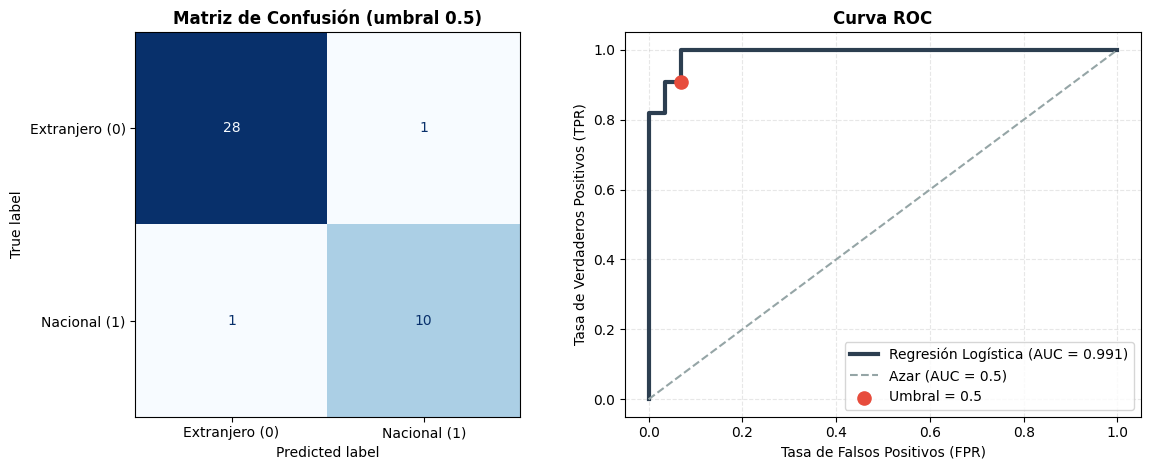

In [11]:
# --- PASO 5.3: ANÁLISIS DEL MODELO ELEGIDO ---
solver_elegido = 'lbfgs'
modelo_final = modelos[solver_elegido]

dif_auc = tabla_solvers['AUC'].max() - tabla_solvers['AUC'].min()
print(f"Diferencia máxima de AUC entre solucionadores: {dif_auc:.6f}")
print(f"Solucionador elegido: {solver_elegido}" + (" (empate técnico → se elige el más simple/estándar)" if dif_auc < 1e-3 else ""))

y_pred = modelo_final.predict(X_test_scaled)
y_prob = modelo_final.predict_proba(X_test_scaled)[:, 1]

print("\n=== Reporte de Clasificación (conjunto de prueba, umbral = 0.5) ===")
print(classification_report(y_test, y_pred, target_names=['Extranjero (0)', 'Nacional (1)'], zero_division=0))

# --- Matriz de confusión + Curva ROC ---
fpr, tpr, umbrales = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

fig, (ax_cm, ax_roc) = plt.subplots(1, 2, figsize=(12, 4.8))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Extranjero (0)', 'Nacional (1)'],
    cmap='Blues', colorbar=False, ax=ax_cm)
ax_cm.grid(False)
ax_cm.set_title('Matriz de Confusión (umbral 0.5)', fontweight='bold')

ax_roc.plot(fpr, tpr, color=COLOR_PRINCIPAL, linewidth=3, label=f'Regresión Logística (AUC = {auc:.3f})')
ax_roc.plot([0, 1], [0, 1], linestyle='--', color=COLOR_NEUTRO, label='Azar (AUC = 0.5)')
idx_05 = np.argmin(np.abs(umbrales - 0.5))                     # punto de operación del umbral 0.5
ax_roc.scatter(fpr[idx_05], tpr[idx_05], color=COLOR_ALERTA, s=90, zorder=5, label='Umbral = 0.5')
ax_roc.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax_roc.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax_roc.set_title('Curva ROC', fontweight='bold')
ax_roc.legend(loc='lower right')

plt.tight_layout()
plt.show()

**Cómo leer estos resultados**

* En el **reporte**, la clase positiva es *Nacional (1)*. *Precision* responde "de los que marqué como Nacional, ¿cuántos lo eran?"; *Recall* responde "de todos los Nacionales reales, ¿cuántos detecté?".
* En la **matriz de confusión**, la diagonal son los aciertos; fuera de la diagonal están los errores (FP y FN). Recuerda que solo son 40 casos.
* En la **ROC**, cuanto más pegada esté la curva a la esquina superior izquierda, mejor. El punto rojo marca dónde opera el modelo con el umbral $0.5$.

### 5.4 Elegir el umbral: el trade-off Precisión vs. Recall

El umbral $0.5$ es solo un valor por defecto. Veamos qué pasa con el resto. En un contexto real, el umbral se elige según el **costo de cada error**: ¿es peor tratar como Nacional un fármaco que no lo era (FP), o dejar pasar uno Nacional (FN)?

In [12]:
# --- PASO 5.4: ANÁLISIS DE UMBRALES ---
filas_u = []
for u in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    pred_u = (y_prob >= u).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_u, labels=[0, 1]).ravel()
    filas_u.append({'Umbral': u,
                    'Precision': precision_score(y_test, pred_u, zero_division=0),
                    'Recall': recall_score(y_test, pred_u),
                    'F1': f1_score(y_test, pred_u, zero_division=0),
                    'FP': fp, 'FN': fn})
display(pd.DataFrame(filas_u).set_index('Umbral').round(3))

# Criterio de Youden: el umbral que maximiza (TPR - FPR), es decir, el punto de la ROC más lejano a la diagonal
umbral_youden = umbrales[np.argmax(tpr - fpr)]
print(f"Umbral óptimo según el índice de Youden (J = TPR - FPR): {umbral_youden:.3f}")
print("⚠️ Con solo 40 casos de prueba este valor es inestable; úsalo como referencia, no como verdad absoluta.")

,Precision,Recall,F1,FP,FN
Umbral,,,,,
0.1,0.500,1.000,0.667,11,0
0.2,0.688,1.000,0.815,5,0
0.3,0.833,0.909,0.870,2,1
0.4,0.833,0.909,0.870,2,1
0.5,0.909,0.909,0.909,1,1
0.6,1.000,0.818,0.900,0,2
0.7,1.000,0.545,0.706,0,5
0.8,1.000,0.455,0.625,0,6
0.9,1.000,0.364,0.533,0,7


Umbral óptimo según el índice de Youden (J = TPR - FPR): 0.285
⚠️ Con solo 40 casos de prueba este valor es inestable; úsalo como referencia, no como verdad absoluta.


* **Umbral bajo** → el modelo marca más casos como Nacional: sube el *recall*, bajan los FN, pero aparecen más FP (baja la *precision*).
* **Umbral alto** → el modelo es más exigente: sube la *precision*, pero se le escapan Nacionales reales (baja el *recall*).
* No existe un umbral "correcto" universal: depende del **costo asimétrico de los errores** en el negocio. El **índice de Youden** es un criterio neutral que pondera igual ambos errores.

### 5.5 Interpretación de los coeficientes

Como las variables están estandarizadas, cada $\beta$ mide el cambio en el log-odds por cada **+1 desviación estándar** de la variable, y $e^{\beta}$ es el *odds ratio* correspondiente.

In [13]:
# --- PASO 5.5: COEFICIENTES DEL MODELO (variables escaladas) ---
coefs_le = pd.DataFrame({
    'Variable': X_codificado.columns,
    'β (por +1 DE)': modelo_final.coef_[0],
    'Odds ratio (e^β)': np.exp(modelo_final.coef_[0]),
}).sort_values('β (por +1 DE)', key=np.abs, ascending=False).reset_index(drop=True)

print(f"Intercepto β0 = {modelo_final.intercept_[0]:.3f}")
display(coefs_le.round(3))

Intercepto β0 = -2.805


,Variable,β (por +1 DE),Odds ratio (e^β)
0,Na_to_K,-3.227,0.040
1,BP,-2.494,0.083
2,Cholesterol,-1.234,0.291
3,Sex,-0.063,0.939
4,Age,0.021,1.021


* **Signo:** $\beta < 0$ → al aumentar la variable, baja la probabilidad de ser Nacional. Recuerda del análisis de datos que un `Na_to_K` alto está asociado a `DrugY` (Extranjero), así que su coeficiente negativo es coherente.
* **Magnitud:** $|\beta|$ cercano a $0$ (*odds ratio* cercano a $1$) indica poca influencia. Compara `Age` y `Sex` con el resto.
* ⚠️ **Precaución con `BP` y `Cholesterol`:** aquí están codificadas con `LabelEncoder`, así que su coeficiente asume una escala numérica arbitraria (alfabética) y **no debe interpretarse "por categoría"**. Para interpretar categorías correctamente necesitamos One-Hot (sección 6).

---
## 6. Nivel Pro: Pipeline de Clasificación Automatizado con OOP

Hasta ahora hicimos cada paso "a mano". Es excelente para aprender, pero frágil para producción:

* Si mañana llega un **paciente nuevo** con datos crudos (`'HIGH'`, `'F'`...), habría que repetir a mano la codificación y el escalado **con exactamente los mismos parámetros** aprendidos en entrenamiento.
* Es fácil cometer **fuga de datos** sin darse cuenta.

La solución es un **`Pipeline`** de `scikit-learn` (preprocesamiento + modelo como un solo objeto) y encapsular el flujo en una **clase** (Programación Orientada a Objetos).

### 6.1 Experimento: ¿importa cómo codificamos las categorías?

Comparamos tres estrategias usando **validación cruzada estratificada de 5 pliegues** dentro de un `Pipeline` (así el escalado y la codificación se ajustan solo con los datos de entrenamiento de cada pliegue):

* **A)** Codificación alfabética (equivalente a `LabelEncoder`): `BP` → `HIGH=0, LOW=1, NORMAL=2`.
* **B)** Codificación ordinal en **orden clínico**: `LOW=0, NORMAL=1, HIGH=2` (lo que un principiante consideraría "más correcto").
* **C)** **One-Hot:** una columna binaria por categoría.

Primero miramos cómo se relaciona `BP` con el objetivo:

In [14]:
# --- PASO 6.1: ¿CÓMO SE RELACIONA BP CON EL PROVEEDOR? ---
print("Proporción de cada clase por nivel de presión arterial (BP):")
display(pd.crosstab(X_features['BP'], y_binario.rename('Proveedor'), normalize='index').round(3)
        .rename(columns={0: 'Extranjero (0)', 1: 'Nacional (1)'}))

Proporción de cada clase por nivel de presión arterial (BP):


Proveedor,Extranjero (0),Nacional (1)
BP,,
HIGH,0.494,0.506
LOW,0.750,0.250
NORMAL,1.000,0.000


In [15]:
# --- PASO 6.1: EXPERIMENTO DE CODIFICACIONES (validación cruzada) ---
columnas_num = ['Age', 'Na_to_K']
columnas_cat = ['Sex', 'BP', 'Cholesterol']
categorias_clinicas = [['F', 'M'], ['LOW', 'NORMAL', 'HIGH'], ['NORMAL', 'HIGH']]

estrategias = {
    'A) Alfabético (= LabelEncoder)':      OrdinalEncoder(),
    'B) Ordinal clínico (LOW<NORMAL<HIGH)': OrdinalEncoder(categories=categorias_clinicas),
    'C) One-Hot':                          OneHotEncoder(handle_unknown='ignore'),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
resultados_enc = []
for nombre, codificador in estrategias.items():
    preprocesador = ColumnTransformer([('num', StandardScaler(), columnas_num),
                                       ('cat', codificador, columnas_cat)])
    pipe = Pipeline([('pre', preprocesador), ('clf', LogisticRegression(max_iter=1000))])
    acc = cross_val_score(pipe, X_features, y_binario, cv=cv, scoring='accuracy')
    auc_cv = cross_val_score(pipe, X_features, y_binario, cv=cv, scoring='roc_auc')
    resultados_enc.append({'Codificación': nombre,
                           'Accuracy (media)': acc.mean(), 'Accuracy (desv.)': acc.std(),
                           'AUC (media)': auc_cv.mean(), 'AUC (desv.)': auc_cv.std()})

display(pd.DataFrame(resultados_enc).set_index('Codificación').round(3))

,Accuracy (media),Accuracy (desv.),AUC (media),AUC (desv.)
Codificación,,,,
A) Alfabético (= LabelEncoder),0.955,0.033,0.988,0.019
B) Ordinal clínico (LOW<NORMAL<HIGH),0.800,0.055,0.860,0.042
C) One-Hot,0.965,0.044,0.989,0.015


**Qué demuestra este experimento**

* La codificación **B (orden clínico)** rinde **mucho peor**, aunque parezca la más "lógica". ¿Por qué? Un modelo lineal asigna **un solo coeficiente** a la variable, así que solo puede representar un efecto **monótono** (siempre creciente o siempre decreciente con la escala). Pero la tabla anterior muestra que la relación de `BP` con el proveedor **no es monótona en el orden clínico**: `NORMAL` (en el medio de la escala) nunca corresponde a Nacional, mientras que `HIGH` y `LOW` sí pueden.
* La codificación **A (alfabética)** funciona bien por **casualidad**: el orden `HIGH, LOW, NORMAL` deja a `NORMAL` en el extremo, y ahí sí el efecto es monótono. Con otro dataset, el orden alfabético podría fallar sin aviso.
* **One-Hot (C)** rinde igual de bien **por la razón correcta**: cada categoría recibe su propio coeficiente, sin imponer ningún orden ni distancia entre ellas. Es la opción segura para categorías **nominales** (sin orden natural) y, con frecuencia, también para ordinales con efectos no monótonos.

> 🧠 **Regla práctica:** usa `OrdinalEncoder` solo cuando exista un orden real **y** esperes un efecto monótono; ante la duda, `OneHotEncoder`.

### 6.2 La clase `ClasificadorProveedorFarmacos`

Diseño de la clase:

| Método | Responsabilidad |
|---|---|
| `cargar_datos` | Lee el CSV, construye el target y hace la partición estratificada |
| `entrenar` | Ajusta el `Pipeline` (escalado + One-Hot + regresión logística) solo con train |
| `evaluar` | Calcula métricas en test con el umbral configurado |
| `validar_cruzado` | Estimación más estable con validación cruzada estratificada |
| `graficar_roc` | Dibuja la curva ROC del conjunto de prueba |
| `predecir_probabilidad` | Devuelve $P(\text{Nacional})$ para un paciente con datos **crudos** |
| `coeficientes` | Tabla de $\beta$ y *odds ratios* con nombres de variables legibles |

Los métodos `cargar_datos` y `entrenar` devuelven `self`, lo que permite **encadenar** llamadas (*method chaining*).

In [16]:
# --- PASO 6.2: PIPELINE DE CLASIFICACIÓN CON OOP ---
class ClasificadorProveedorFarmacos:
    """Clasifica un fármaco como Nacional (1) o Extranjero (0) con Regresión Logística.

    El preprocesamiento (escalado + One-Hot) vive DENTRO del Pipeline, por lo que:
      * se ajusta únicamente con datos de entrenamiento (sin fuga de datos), y
      * se aplica automáticamente a pacientes nuevos con datos crudos.
    """
    PROVEEDOR_POR_FARMACO = {'druga': 1, 'drugb': 1, 'drugc': 1,    # Nacional
                             'drugx': 0, 'drugy': 0}                # Extranjero
    COLUMNAS_NUM = ['Age', 'Na_to_K']
    COLUMNAS_CAT = ['Sex', 'BP', 'Cholesterol']

    def __init__(self, solver='lbfgs', C=1.0, umbral=0.5, test_size=0.2, random_state=42):
        self.solver = solver
        self.C = C                       # inverso de la fuerza de regularización L2
        self.umbral = umbral             # umbral de decisión sobre la probabilidad
        self.test_size = test_size
        self.random_state = random_state
        self.pipeline_ = None

    # ---------- datos ----------
    def cargar_datos(self, ruta_csv):
        df = pd.read_csv(ruta_csv)
        y = df['Drug'].str.strip().str.lower().map(self.PROVEEDOR_POR_FARMACO)
        if y.isna().any():
            raise ValueError(f"Fármacos no contemplados: {df.loc[y.isna(), 'Drug'].unique()}")
        self.X_ = df[self.COLUMNAS_NUM + self.COLUMNAS_CAT]
        self.y_ = y.astype(int)
        (self.X_train_, self.X_test_,
         self.y_train_, self.y_test_) = train_test_split(
            self.X_, self.y_, test_size=self.test_size,
            random_state=self.random_state, stratify=self.y_)
        return self

    # ---------- modelo ----------
    def _construir_pipeline(self):
        preprocesador = ColumnTransformer([
            ('num', StandardScaler(), self.COLUMNAS_NUM),
            ('cat', OneHotEncoder(handle_unknown='ignore'), self.COLUMNAS_CAT),
        ])
        clasificador = LogisticRegression(solver=self.solver, C=self.C,
                                          max_iter=1000, random_state=self.random_state)
        return Pipeline([('preprocesamiento', preprocesador), ('clasificador', clasificador)])

    def entrenar(self):
        self.pipeline_ = self._construir_pipeline().fit(self.X_train_, self.y_train_)
        return self

    # ---------- evaluación ----------
    def evaluar(self):
        prob = self.pipeline_.predict_proba(self.X_test_)[:, 1]
        pred = (prob >= self.umbral).astype(int)
        return {'Accuracy': accuracy_score(self.y_test_, pred),
                'Precision': precision_score(self.y_test_, pred, zero_division=0),
                'Recall': recall_score(self.y_test_, pred),
                'F1': f1_score(self.y_test_, pred),
                'AUC': roc_auc_score(self.y_test_, prob),
                'Log-loss': log_loss(self.y_test_, prob)}

    def validar_cruzado(self, k=5):
        cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=self.random_state)
        pipe = self._construir_pipeline()          # pipeline nuevo: ajusta el preprocesamiento en cada pliegue
        out = {}
        for nombre, scoring in [('Accuracy', 'accuracy'), ('AUC', 'roc_auc')]:
            puntajes = cross_val_score(pipe, self.X_, self.y_, cv=cv, scoring=scoring)
            out[nombre] = (puntajes.mean(), puntajes.std())
        return out

    def graficar_roc(self, ax=None):
        prob = self.pipeline_.predict_proba(self.X_test_)[:, 1]
        fpr, tpr, _ = roc_curve(self.y_test_, prob)
        ax = ax or plt.subplots(figsize=(5.5, 5))[1]
        ax.plot(fpr, tpr, color=COLOR_PRINCIPAL, linewidth=3,
                label=f'ROC (AUC = {roc_auc_score(self.y_test_, prob):.3f})')
        ax.plot([0, 1], [0, 1], linestyle='--', color=COLOR_NEUTRO, label='Azar')
        ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
        ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
        ax.set_title(f'ROC — solver: {self.solver}', fontweight='bold')
        ax.legend(loc='lower right')
        return ax

    # ---------- uso en producción ----------
    def predecir_probabilidad(self, **paciente):
        """P(Nacional) para un paciente con datos crudos. Ej.: Age=45, Sex='F', BP='HIGH', ..."""
        fila = pd.DataFrame([paciente])[self.COLUMNAS_NUM + self.COLUMNAS_CAT]
        return float(self.pipeline_.predict_proba(fila)[0, 1])

    def coeficientes(self):
        nombres = self.pipeline_.named_steps['preprocesamiento'].get_feature_names_out()
        beta = self.pipeline_.named_steps['clasificador'].coef_[0]
        return (pd.DataFrame({'Variable': nombres, 'β': beta, 'Odds ratio (e^β)': np.exp(beta)})
                .sort_values('β', key=np.abs, ascending=False).reset_index(drop=True))

print("✅ Clase definida.")

✅ Clase definida.


### 6.3 Uso de la clase

Entrenamos, evaluamos y validamos el modelo en una sola cadena de llamadas.

=== Métricas en el conjunto de prueba (umbral = 0.5) ===
Accuracy  : 0.975
Precision : 1.000
Recall    : 0.909
F1        : 0.952
AUC       : 0.994
Log-loss  : 0.191

=== Validación cruzada estratificada (5 pliegues): media ± desviación ===
Accuracy  : 0.965 ± 0.044
AUC       : 0.989 ± 0.015


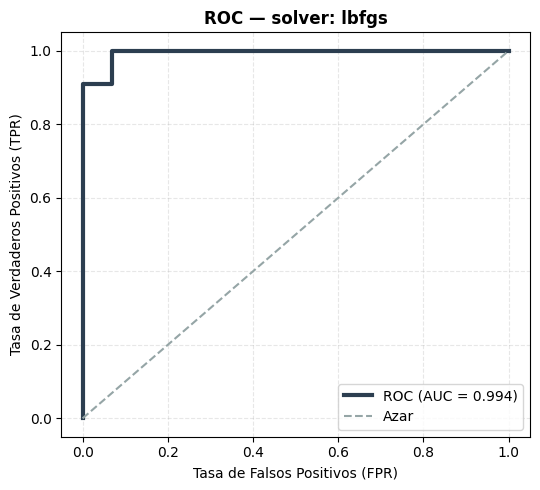

In [17]:
# --- PASO 6.3: ENTRENAR Y EVALUAR CON LA CLASE ---
clf = ClasificadorProveedorFarmacos(solver='lbfgs').cargar_datos('drugs.csv').entrenar()

print("=== Métricas en el conjunto de prueba (umbral = 0.5) ===")
for nombre, valor in clf.evaluar().items():
    print(f"{nombre:10s}: {valor:.3f}")

print("\n=== Validación cruzada estratificada (5 pliegues): media ± desviación ===")
for nombre, (media, desv) in clf.validar_cruzado().items():
    print(f"{nombre:10s}: {media:.3f} ± {desv:.3f}")

clf.graficar_roc()
plt.tight_layout()
plt.show()

**Comparación de solucionadores con el pipeline completo:** ahora que el flujo es un objeto, repetir el experimento de la sección 5 es un bucle de tres líneas.

In [18]:
# --- COMPARATIVA DE SOLUCIONADORES USANDO LA CLASE ---
filas = []
for solver in SOLVERS:
    m = ClasificadorProveedorFarmacos(solver=solver).cargar_datos('drugs.csv').entrenar()
    met, cv_res = m.evaluar(), m.validar_cruzado()
    filas.append({'Solver': solver,
                  'Accuracy (test)': met['Accuracy'], 'AUC (test)': met['AUC'],
                  'Accuracy (CV)': cv_res['Accuracy'][0], 'AUC (CV)': cv_res['AUC'][0]})
display(pd.DataFrame(filas).set_index('Solver').round(4))

,Accuracy (test),AUC (test),Accuracy (CV),AUC (CV)
Solver,,,,
lbfgs,0.975,0.9937,0.965,0.9893
newton-cg,0.975,0.9937,0.965,0.9893
sag,0.975,0.9937,0.965,0.9893
saga,0.975,0.9937,0.965,0.9893


### 6.4 Modelado de probabilidades: predecir para pacientes nuevos

La gran ventaja del `Pipeline`: le pasamos datos **crudos** y devuelve una **probabilidad**. Abajo, tres pacientes hipotéticos con perfiles distintos, y el modelo nos dice qué tan probable es que el fármaco adecuado sea de proveedor Nacional.

In [19]:
# --- PASO 6.4: PROBABILIDADES PARA PACIENTES NUEVOS (datos crudos) ---
pacientes = {
    'Paciente 1 (BP alta, Na_to_K bajo)':    dict(Age=45, Sex='F', BP='HIGH',   Cholesterol='HIGH',   Na_to_K=10.5),
    'Paciente 2 (BP normal, Na_to_K bajo)':  dict(Age=30, Sex='M', BP='NORMAL', Cholesterol='NORMAL', Na_to_K=8.0),
    'Paciente 3 (BP alta, Na_to_K muy alto)': dict(Age=45, Sex='F', BP='HIGH',   Cholesterol='HIGH',   Na_to_K=25.0),
}
for nombre, datos in pacientes.items():
    p = clf.predecir_probabilidad(**datos)
    decision = 'Nacional' if p >= clf.umbral else 'Extranjero'
    print(f"{nombre:42s} -> P(Nacional) = {p:.3f}  =>  {decision}")

print("\n=== Coeficientes con One-Hot (ahora sí interpretables por categoría) ===")
display(clf.coeficientes().round(3))

Paciente 1 (BP alta, Na_to_K bajo)         -> P(Nacional) = 0.952  =>  Nacional
Paciente 2 (BP normal, Na_to_K bajo)       -> P(Nacional) = 0.048  =>  Extranjero
Paciente 3 (BP alta, Na_to_K muy alto)     -> P(Nacional) = 0.052  =>  Extranjero

=== Coeficientes con One-Hot (ahora sí interpretables por categoría) ===


,Variable,β,Odds ratio (e^β)
0,num__Na_to_K,-2.844,0.058
1,cat__BP_NORMAL,-2.527,0.080
2,cat__BP_HIGH,2.369,10.682
3,cat__Cholesterol_NORMAL,-0.981,0.375
4,cat__Cholesterol_HIGH,0.981,2.666
5,cat__BP_LOW,0.158,1.171
6,num__Age,0.047,1.049
7,cat__Sex_M,-0.045,0.956
8,cat__Sex_F,0.044,1.045


**Cómo leer los coeficientes One-Hot**

* Cada fila `cat__BP_HIGH`, `cat__BP_LOW`, `cat__BP_NORMAL` tiene su **propio** $\beta$: ya no imponemos ningún orden entre categorías.
* Una categoría con $\beta$ **muy negativo** (odds ratio $\ll 1$) empuja fuertemente la probabilidad hacia *Extranjero* (por ejemplo, `BP_NORMAL`); una con $\beta$ positivo la empuja hacia *Nacional*.
* Las variables numéricas (`num__...`) siguen estandarizadas: su $\beta$ es por **+1 desviación estándar**.
* Con One-Hot y regularización L2, el efecto de una variable binaria se reparte entre sus dos columnas (`Sex_F` / `Sex_M`, `Cholesterol_HIGH` / `Cholesterol_NORMAL`); interpreta el **contraste** entre ambas.

---
## 7. Glosario Técnico, Errores Comunes y Conclusión

### 📖 Glosario

| Término | Definición breve |
|---|---|
| **Sigmoide / función logística** | $S(z) = 1/(1+e^{-z})$. Transforma cualquier número real en una probabilidad en $(0,1)$. |
| **Logit (log-odds)** | $\ln\big(p/(1-p)\big)$. Es la cantidad que el modelo expresa como combinación lineal de las variables. |
| **Odds** | Razón $p/(1-p)$. Con $p=0.8$, los odds son $4$. |
| **Odds ratio ($e^{\beta}$)** | Factor por el que se multiplican los odds al aumentar la variable una unidad. |
| **Máxima Verosimilitud (MLE)** | Método que elige los $\beta$ que hacen más probables las etiquetas observadas. |
| **Log-loss (entropía cruzada)** | Pérdida que la regresión logística minimiza; penaliza fuertemente las predicciones seguras y equivocadas. |
| **Regularización L2 / parámetro `C`** | Penalización sobre el tamaño de los coeficientes. `C` es su **inverso**: menor `C` = más regularización. |
| **Solucionador (*solver*)** | Algoritmo numérico que optimiza la log-loss (`lbfgs`, `newton-cg`, `sag`, `saga`...). |
| **Umbral de clasificación** | Probabilidad a partir de la cual se decide "clase positiva" (por defecto $0.5$). |
| **Matriz de confusión** | Tabla de aciertos y errores: VP, VN, FP, FN. |
| **Sensibilidad / *Recall* / TPR** | $VP/(VP+FN)$. Proporción de positivos reales detectados. |
| **Especificidad** | $VN/(VN+FP)$. Proporción de negativos reales correctamente descartados. Es $1-\text{FPR}$. |
| **Precisión (*Precision*)** | $VP/(VP+FP)$. De los marcados como positivos, cuántos lo eran. |
| **F1** | Media armónica de *precision* y *recall*. |
| **Curva ROC** | TPR vs. FPR para todos los umbrales posibles. |
| **AUC** | Área bajo la ROC: probabilidad de ordenar bien un par (positivo, negativo). $0.5$ = azar, $1$ = perfecto. |
| **Línea base (*baseline*)** | Modelo trivial (p. ej. predecir siempre la clase mayoritaria) contra el que se compara. |
| **Fuga de datos (*data leakage*)** | Que información del conjunto de prueba influya en el entrenamiento (p. ej. ajustar el escalador con todos los datos). |
| **Estratificación** | Dividir los datos conservando la proporción de clases en cada parte. |
| **One-Hot Encoding** | Convierte una categoría en columnas binarias, sin imponer orden entre categorías. |
| **`Pipeline`** | Objeto que encadena preprocesamiento y modelo, garantizando que se apliquen siempre igual. |

### ⚠️ Errores comunes (y cómo evitarlos)

1. **Usar `LabelEncoder` en variables predictoras** → impone un orden numérico arbitrario. Usa `OneHotEncoder` (o `OrdinalEncoder` solo si hay orden real y efecto monótono).
2. **Ajustar el `StandardScaler` con todos los datos** → fuga de datos. Ajusta solo con *train* (o mejor: dentro de un `Pipeline`).
3. **Fiarse solo de la *accuracy* con clases desbalanceadas** → compara siempre contra la línea base y revisa *precision*, *recall*, AUC y log-loss.
4. **Aceptar el umbral $0.5$ sin pensar** → el umbral correcto depende del costo de cada tipo de error.
5. **Evaluar con un solo *split* pequeño** → añade validación cruzada para conocer la variabilidad.
6. **Interpretar coeficientes de variables sin escalar o con codificación arbitraria** → estandariza y usa One-Hot antes de interpretar.
7. **Ignorar `ConvergenceWarning`** → indica que el solucionador no llegó al óptimo: escala las variables o aumenta `max_iter`.

### 🏁 Conclusión

* La regresión logística **modela la probabilidad** de la clase positiva aplicando la sigmoide a una combinación lineal; sus coeficientes son **log-odds** y se interpretan mediante *odds ratios*.
* Se entrena por **máxima verosimilitud** (penalizada con L2 en `scikit-learn`). Como la log-loss es convexa, **todos los solucionadores correctos llegan al mismo modelo**; difieren en velocidad, memoria y penalizaciones soportadas.
* **Escalar** es crítico para `sag`/`saga` y buena práctica siempre; **codificar bien** las categóricas puede marcar la diferencia entre un modelo excelente y uno mediocre.
* Evaluar bien es tan importante como entrenar: línea base, ROC/AUC, umbral según el negocio y validación cruzada.
* Empaquetar el flujo en un `Pipeline` (y en una clase) lo vuelve **reproducible, libre de fuga de datos y listo para predecir con datos crudos**.

### 🧪 Ejercicios propuestos

1. Entrena la clase con `C = 0.01`, `1` y `100`. ¿Cómo cambian los coeficientes y el AUC? ¿Qué significa regularizar más?
2. Suponiendo que un **falso negativo** (dejar pasar un fármaco Nacional) cuesta el triple que un falso positivo, ¿qué umbral elegirías? Justifícalo con la tabla de la sección 5.4.
3. Prueba `class_weight='balanced'` en `LogisticRegression`. ¿Qué pasa con *precision* y *recall*?
4. Entrena con `solver='saga'` usando penalización L1 (consulta la documentación de tu versión de `scikit-learn` para la sintaxis) y observa qué coeficientes se vuelven exactamente cero.
5. **Reto:** en lugar de agrupar en Nacional/Extranjero, intenta predecir los **5 fármacos** directamente (regresión logística multinomial). ¿Qué métricas cambian?

### 🧠 Autoevaluación

<details><summary><b>1. ¿Por qué la regresión logística no usa mínimos cuadrados?</b></summary>

Porque la variable objetivo es binaria y necesitamos probabilidades en $(0,1)$. Se modela el log-odds como función lineal y se estiman los coeficientes por máxima verosimilitud minimizando la log-loss.
</details>

<details><summary><b>2. Si $\beta_j = 0.7$, ¿cómo cambian los odds al subir $X_j$ en una unidad?</b></summary>

Se multiplican por $e^{0.7} \approx 2.01$: los odds se duplican aproximadamente (con las demás variables constantes).
</details>

<details><summary><b>3. Un modelo tiene AUC = 0.5. ¿Qué significa?</b></summary>

Que no discrimina mejor que el azar: la ROC coincide con la diagonal.
</details>

<details><summary><b>4. ¿Por qué ajustar el escalador solo con el conjunto de entrenamiento?</b></summary>

Para evitar fuga de datos: la media y la desviación del conjunto de prueba no deben influir en el entrenamiento; simulamos así cómo se comportará el modelo con datos realmente nuevos.
</details>

<details><summary><b>5. Los cuatro solucionadores dieron las mismas métricas. ¿Es un error?</b></summary>

No. La log-loss es convexa y tiene un único mínimo global, así que solucionadores correctamente convergidos deben llegar (casi) a los mismos coeficientes. Se diferencian en eficiencia y en las penalizaciones que soportan.
</details>

---
*Fin del Tema 25. ¡Buen trabajo! 🎉*